In [ ]:
import numpy as np
import cv2
import time
import matplotlib.pyplot as plt
from PIL import Image
import os

In [181]:
name='121.jpg'
_path1 = os.path.join(r'C:\Users\hp\Desktop\tc_data\150x70\rust\imgs', name)
save_path = os.path.join(r'C:\Users\hp\Desktop\tc_data\150x70\rust\kmForPs', name)
img = np.array(Image.open(_path1))
print(img.shape)

(512, 1096, 3)


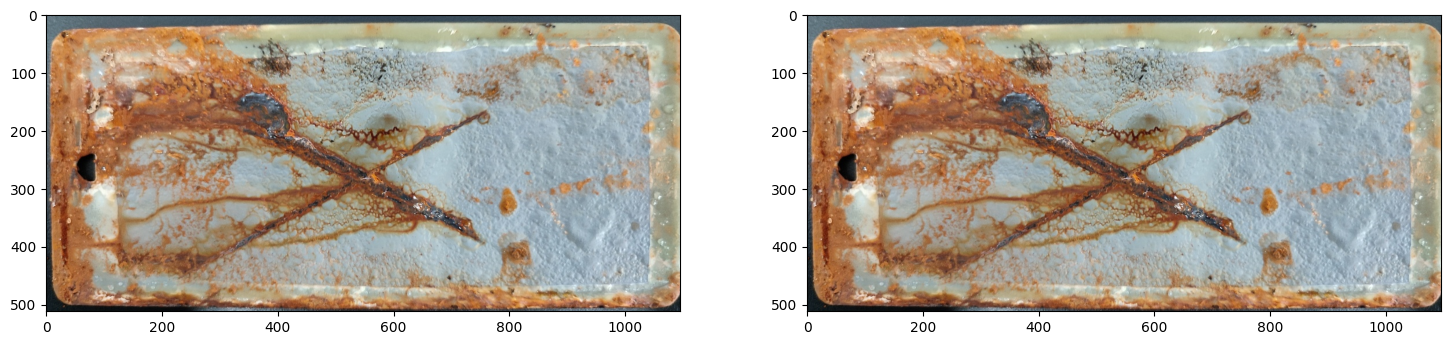

In [182]:
plt.figure(figsize=(18,24))
plt.subplot(1,2,1)
plt.imshow(img)
img_roi = img.copy()
plt.subplot(1,2,2)
plt.imshow(img_roi)

In [169]:
data = img_roi / 255.0 # use 0...1 scale
data = data.reshape(-1, 3)

In [170]:
from sklearn.cluster import MiniBatchKMeans, KMeans
# _kmeans = MiniBatchKMeans(5)
_kmeans = KMeans(n_clusters=5, random_state=0)

_kmeans.fit(data)
# new_colors = _kmeans.cluster_centers_[_kmeans.predict(data)]
pixel_centers = (_kmeans.cluster_centers_*255).astype(np.uint8)
# print(_kmeans.cluster_centers_*255)

In [171]:
s = _kmeans.predict(data)
new_colors = pixel_centers[s]

In [172]:
img_recolored = new_colors.reshape(img.shape)

# img_recolored = (img_recolored*255).astype(np.uint8)

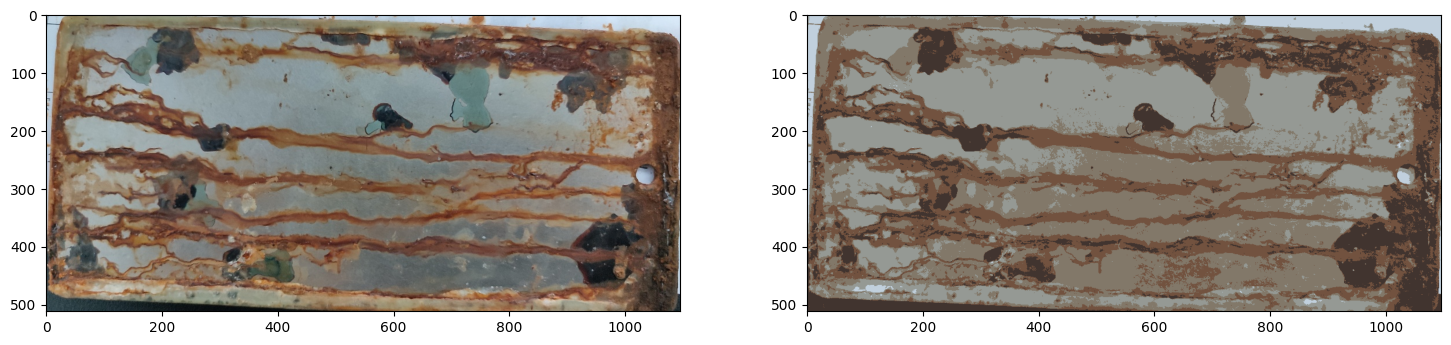

In [173]:
plt.figure(figsize=(18,12))
plt.subplot(1,2,1)
plt.imshow(img)
plt.subplot(1,2,2)
plt.imshow(img_recolored)

In [174]:
# 保存图片
_saved_img = Image.fromarray(img_recolored)
_saved_img.save(save_path)

In [ ]:
new_mask = np.ones((img_recolored.shape[0], img_recolored.shape[1]), dtype=np.uint8)*255
color = pixel_centers[0]
_mask = np.logical_and(img_recolored[:,:,0]==color[0], img_recolored[:,:,1]==color[1])
_mask = np.logical_and(_mask, img_recolored[:,:,2]==color[2])
new_mask[_mask] = 0
plt.imshow(new_mask, cmap='gray')